If you are playing this game on terminal, make sure to close the plots in order to proceed to the next question, and always press the spacebar once before typing your answer!


Pick your starter star! Type 1 for a sun-like star, and 2 for a massive star! 2


Fetching data from Gaia...


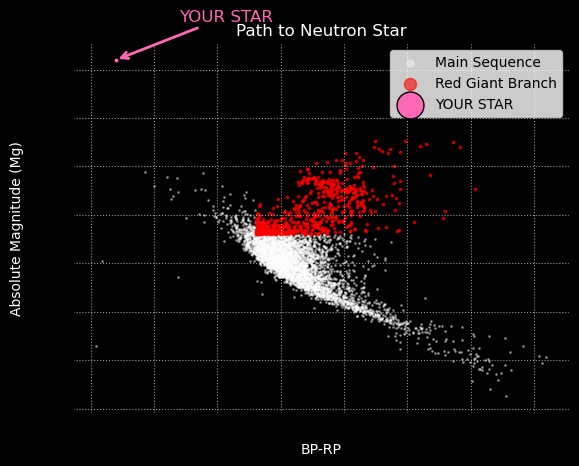

Your star dreams of becoming a neutron star... your mission is to correctly answer questions in order to help it!
At the beginning of its life, your star lies on the main sequence... during this time, what element is fused into helium in its core?


Element: hydrogen


You are correct! Main sequence stars burn hydrogen into helium in their cores
Your star seems to be running out of hydrogen quite quickly... But your star is quite massive, so thats normal!
Your star is no longer on the main sequence because it's all out of hydrogen!


What kind of star is it now? red supergiant


You are correct! Your star is now a red supergiant
Your star is now starting to burn heavier and heavier elements in its core... it's well on its way to becoming a neutron star!
It's like an onion... but it's burning up fast


What is the heaviest element that is fused at the core of a red supergiant? iron


You are correct! Your star can fuse elements up to iron!


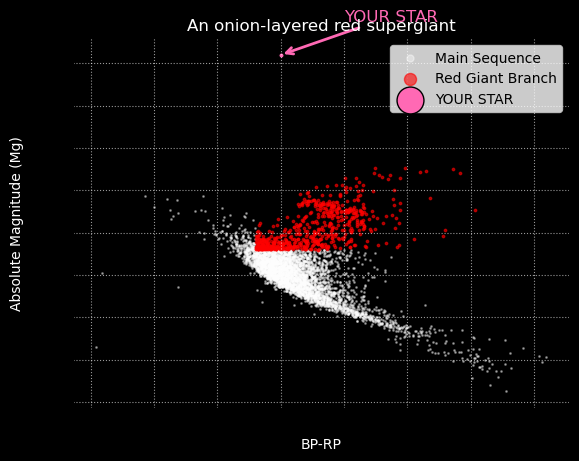

Wait... all thats left is the iron core, all the other layers are used up!
Fusion is no longer producing energy to balance out the gravity...


Fill in the blank. The star is no longer in '___' equilibrium  hydrostatic


You are correct! As fusion in the core stops, there is not enough outwards pressure, gravity wins and your stars core contracts
Your stars core collapsed in seconds... you only need to answer one more question to help it become a neutron star!


What has the massive explosion of your star become? supernova


You are correct! Extremely heavy elements are formed from this supernova!
What remains after the supernova is..... a NEUTRON STAR!!


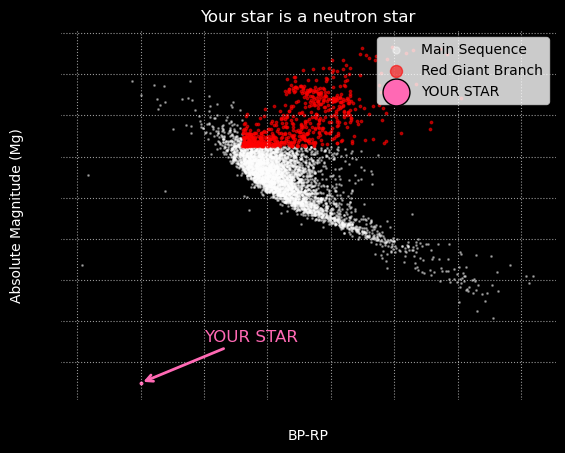

You have successfully helped your star acheive its dream, you win at PROGNUM


In [2]:
from matplotlib.pyplot import figure, show
import numpy as np
from astroquery.gaia import Gaia
import sys

class Game: #defining a new class with the functions used in my game
    """
    A class providing tools and mechanics for my astronomy-based game
    using Gaia data.


    Attributes
    ----------
    data : astropy.table.Table
        Table of stellar data retrieved from Gaia DR3.
    Mg : numpy.ndarray
        Absolute magnitude of stars in the G band.
    color : numpy.ndarray
        BP-RP color index of stars.
    """
    def __init__(self):
        """
        Initialize the game and queries the Gaia data.

        Notes
        -----
        - Uses astroquery.gaia to fetch data.
        - Absolute magnitude is computed from parallax and apparent magnitude.
        - Color is defined as BP-RP.
        """
        
        print("Fetching data from Gaia...") #using astroquery
        query = """
        SELECT TOP 5000 source_id, parallax, phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag 
        FROM gaiadr3.gaia_source
        WHERE parallax > 0.5
        AND phot_g_mean_mag < 15
        AND phot_bp_mean_mag IS NOT NULL
        AND phot_rp_mean_mag IS NOT NULL
        """
        #the data selected is so that it is likely that I will get quite bright stars (up to -15 mag), as well as stars where i can plot the bp-rp color
        
        self.data = Gaia.launch_job(query).get_results()
    
        self.Mg = self.data['phot_g_mean_mag'] + 5 * np.log10(self.data['parallax'] / 1000) + 5 #using the apparent magnitude to get the absolute magnitude
        self.color = self.data['phot_bp_mean_mag'] - self.data['phot_rp_mean_mag'] #defining teh color as bp-rp

    def plot_hr(self, star_x, star_y, title, stage="Main Sequence"):
        """
        Plot a Hertzsprung–Russell diagram with Gaia data

        Parameters
        ----------
        star_x : float
            BP-RP color index of the users star.
        star_y : float
            Absolute magnitude of the users star.
        title : str
            Title of the plot.

        Notes
        -----
        - Main sequence and red giant stars are separated using masks.
        """
       
        mask_rg = (self.Mg < 3.5) & (self.color > 0.8) #making a mask for red giants using the p-revious requirements
        mask_ms = ~mask_rg #the ms mask is the rest of the data outside of the rg mask

        fig = figure(facecolor='black') #using oop plotting 
        ax = fig.add_subplot(facecolor='black')

        ax.scatter(self.color[mask_ms], self.Mg[mask_ms], #plotting the main sequence stars 
               s=1, color='white', alpha=0.4, label='Main Sequence')

        ax.scatter(self.color[mask_rg], self.Mg[mask_rg], #plotting teh red giant stars
               s=3, color='red', alpha=0.6, label='Red Giant Branch')
        
        ax.scatter(star_x, star_y, s=15, color='hotpink', #plotting the users star with teh variables being the input coordinates 
                   edgecolors='black', label='YOUR STAR')
        
        ax.annotate( #making it so that there's an arrow on the users star
            f'YOUR STAR', 
            xy=(star_x, star_y), #pos of the tip of the arrow
            xytext=(star_x + 0.5, star_y - 2), 
            fontsize=12,
            color='hotpink',
            arrowprops=dict(
                arrowstyle="->",
                color='hotpink', 
                lw=2,
            )
        )

        ax.invert_yaxis() #inverting the y axis because of how mags work
        ax.set_xlabel('BP-RP', color='white')
        ax.set_ylabel('Absolute Magnitude (Mg)', color='white')
        ax.legend(loc='upper right', markerscale=5)
        ax.set_title(title, color="white")
        ax.grid(True, linestyle=':', alpha=0.6, color='white')

        show()

    def ask_question(self, question, correct_answer, hint, success_message=None):
        
        """
        Ask the user a question with up to two attempts.

        Parameters
        ----------
        question : str
            The question displayed to the user.
        correct_answer : str
            The correct answer.
        hint : str
            Hint displayed after the first incorrect attempt.
        success_message : str
            Message displayed if the user answers correctly.

        Notes
        -----
        - The user has two attempts to answer correctly.
        - Input is put in lowercase and stripped of accidental spaces.
        - If both attempts fail, the program exits.
        """
        
        attempts = 0 #making sure that it resets the attempts to 0 each time its called
        answered = False #the question is predefined as not answered

        while attempts<2 and not answered: #giving the player only two attempts
            if attempts==0: #first try for the user
                user_input = input(question).strip().lower() #making sure that the input is no accidental spaces or capital letters
            else:
                print(hint) #Second attempt, the hint is one of the args of the function
                user_input = input("Try again: ").strip().lower() #second input

            if user_input == correct_answer: #correct answer is an arg
                    print(success_message) #the success message is also an arg
                    answered = True
            else:
                attempts += 1 #adding up the attempts 

        if not answered:
            print("You were not able to help your star achieve its dream:(, start again")
            sys.exit() #making restart if failed

#end of the class def, beginning of the actual game code
print("If you are playing this game on terminal, make sure to close the plots in order to proceed to the next question, and always press the spacebar once before typing your answer!")
bs=int(input("Pick your starter star! Type 1 for a sun-like star, and 2 for a massive star!")) 
game=Game() #calling on the class

if bs==1: #sun-like star
    game.plot_hr(0.82, 4.67, "Path to White Dwarf") #using the suns coordinates
   

    #1st question

    print("Your star dreams of becoming a white dwarf... your mission is to correctly answer questions in order to help it!")
    print("At the beginning of its life, your star lies on the main sequence... during this time, what element is fused into helium in its core?")
   
    game.ask_question( #using the defined function with the corresponding arguments
        "Element:",
        "hydrogen",
        "Here is a hint... its atomic number is 1",
        "You are correct! Main sequence stars burn hydrogen into helium in their cores"
    )

    game.plot_hr(0.95, 4, "Moving along the MS") #plotting it moving along (vaguely, not too precise)


    #2nd question
    
    print("Uh oh... your star seems to be running out of hydrogen. But this is normal! Help your star get to the next step")

    game.ask_question(
    "Fill in the blank. The star is no longer in '___' equilibrium ",
    "hydrostatic",
    "Here is a hint... it starts with h",
    "You are correct! As fusion in the core stops, there is not enough outwards pressure, gravity wins and your stars core contracts"
    )

    #3rd question
    
    print("Your star is growing and shedding its outer layers expanding! Your star is no longer a main sequence star.")
    
    game.ask_question(
    "What kind of star has it become",
    "red giant",
    "Here is a hint... it has the colour red in it",
    "You are correct! Your star has evolved into a red giant"
    )
    
    game.plot_hr(2.5, 0, "Your star in the RGB") #somewhere on bteh red giant branch

    #last and 4th question 

    print("A new kind of fusion starts, your star is now fusing helium causin a...")
    print("HELIUM FLASH")

    print("ALERT: The outer layers of your star are being pushed apart!!! What are they becoming?")
    
    game.ask_question(
    "They will become a ___ ___",
    "planetary nebula",
    "Here is a hint... the first word of two is planetary",
    "You are correct! Your star has just produced a planetary nebula"
    )
    
    print("What remains of your star is a dense hot core... also known as A WHITE DWARF!")
    print("You have successfully helped your star achieve its dream, you win at PROGNUM")
    
    game.plot_hr(0.3, 12.5, "Your star is a white dwarf") #in the white dwarf region

elif bs==2: #massive star
    game.plot_hr(-0.3, -5.5, "Path to Neutron Star") #plotting the initial position of a star on ms but more massiveb than sun
    # 1st question
    
    print("Your star dreams of becoming a neutron star... your mission is to correctly answer questions in order to help it!")
    print("At the beginning of its life, your star lies on the main sequence... during this time, what element is fused into helium in its core?")
    
    game.ask_question(
        "Element:",
        "hydrogen",
        "Here is a hint... its atomic number is 1",
        "You are correct! Main sequence stars burn hydrogen into helium in their cores"
    )

    #2nd question
    
    print("Your star seems to be running out of hydrogen quite quickly... But your star is quite massive, so thats normal!")
    print("Your star is no longer on the main sequence because it's all out of hydrogen!")

    game.ask_question(
        "What kind of star is it now?",
        "red supergiant",
        "Here is a hint... it has the word red in it",
        "You are correct! Your star is now a red supergiant"
    )

    #3rd question
    
    print("Your star is now starting to burn heavier and heavier elements in its core... it's well on its way to becoming a neutron star!")
    print("It's like an onion... but it's burning up fast")

    game.ask_question(
        "What is the heaviest element that is fused at the core of a red supergiant?",
        "iron",
        "Here is a hint... it has the atomic number 26",
        "You are correct! Your star can fuse elements up to iron!"
    )

    game.plot_hr(1, -8, "An onion-layered red supergiant") #in teh red supergiant region

    #4th question
    
    print("Wait... all thats left is the iron core, all the other layers are used up!")
    print("Fusion is no longer producing energy to balance out the gravity...")

    game.ask_question(
        "Fill in the blank. The star is no longer in '___' equilibrium ",
        "hydrostatic",
        "Here is a hint... it starts with h",
        "You are correct! As fusion in the core stops, there is not enough outwards pressure, gravity wins and your stars core contracts"
    )

    #5th and final question
    
    print("Your stars core collapsed in seconds... you only need to answer one more question to help it become a neutron star!")
    
    game.ask_question(
        "What has the massive explosion of your star become?",
        "supernova",
        "Here is a hint... it's 'super' ",
        "You are correct! Extremely heavy elements are formed from this supernova!"
    )

    print("What remains after the supernova is..... a NEUTRON STAR!!")

    uhoh= np.random.choice(["a", "b"]) #making it so that there's a 50/50 chanc ethat you dont win, even after succeeding

    if uhoh=="a":
        game.plot_hr(0, 15, "Your star is a neutron star") #the good ending, you win
        print("You have successfully helped your star acheive its dream, you win at PROGNUM")
        
    elif uhoh=="b":
        print("...or is it...") #the bad ending... your star is a black hole
        print("Your stars remaining core was too massive.... IT IS NOW A BLACK HOLE")

